In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [ ]:
#Load Data
df = pd.read_csv("data/house_prices.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nMissing values ratio:")
print(df.isna().mean().sort_values(ascending=False))

Shape: (187531, 21)

First 5 rows:


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16

In [ ]:
#Data Cleaning
# Clean Amount
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"]).copy()

# Clean Carpet Area
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "sqft" in x:
            return float(x.replace("sqft", "").strip())
        if "sqm" in x:
            return float(x.replace("sqm", "").strip()) * 10.764
        return float(x)
    except ValueError:
        return None

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)

# Clean Floor
def parse_floor(x):
    if not isinstance(x, str):
        return 0
    x = x.strip().lower()
    if "ground" in x or "basement" in x:
        return 0
    try:
        return int(x.split("out")[0].strip())
    except Exception:
        return 0

df["floor_num"] = df["Floor"].apply(parse_floor)

# Numeric Columns
for col in ["bathroom", "balcony"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (177847, 24)


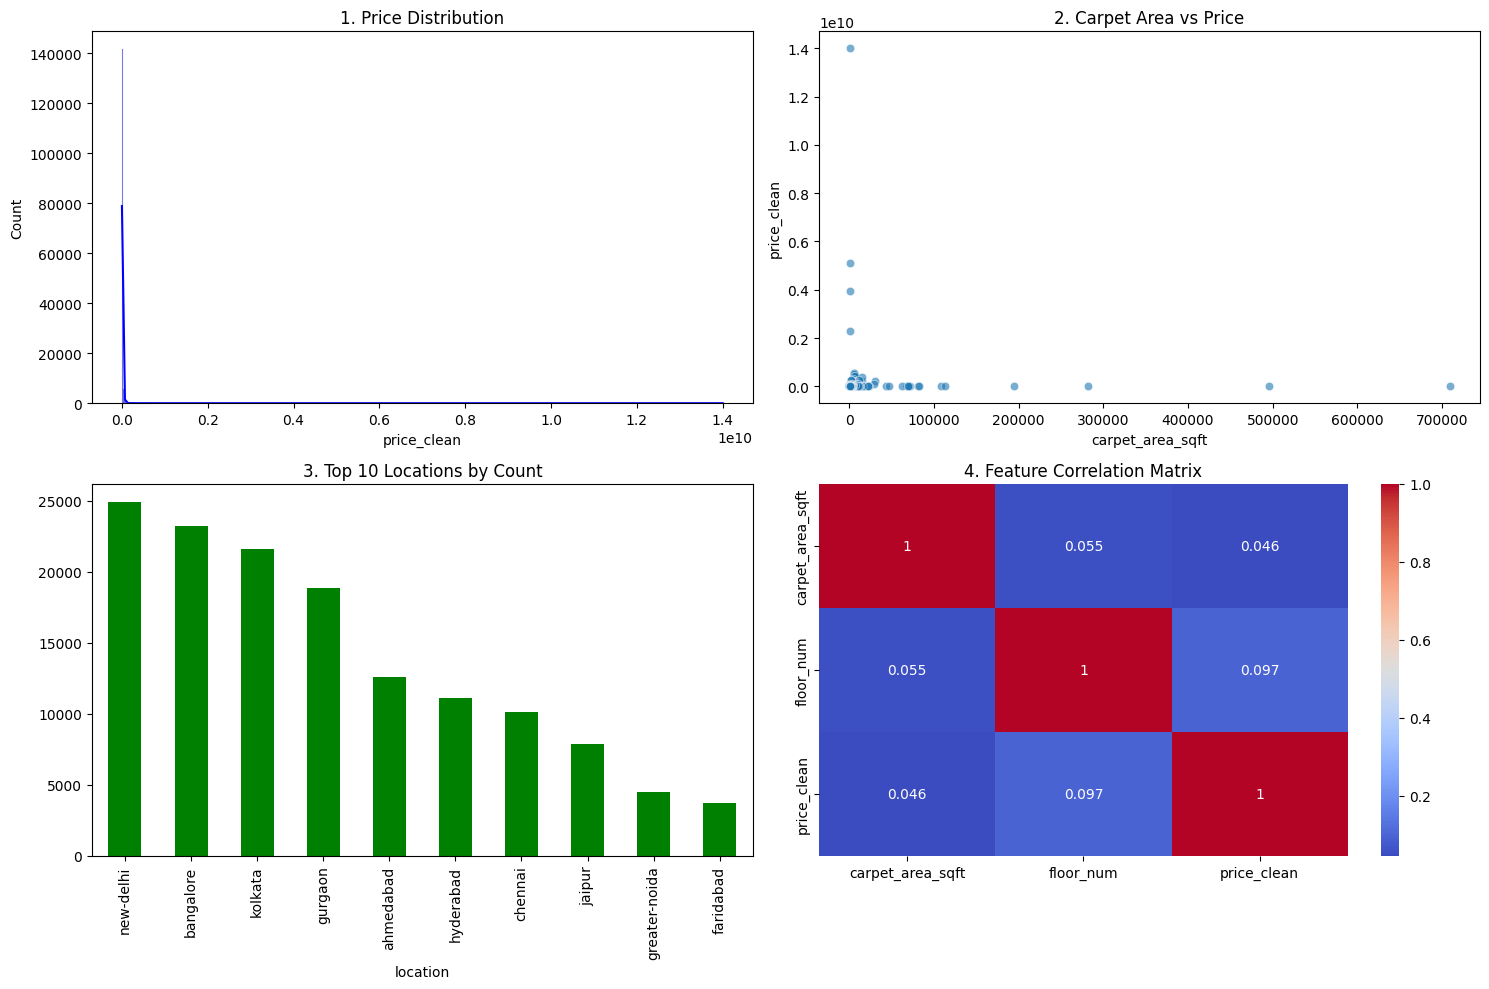

In [ ]:
#Exploratory Data Analysis (EDA)
plt.figure(figsize=(15, 10))

# Chart 1: Price Distribution
plt.subplot(2, 2, 1)
sns.histplot(df["price_clean"], kde=True, color="blue")
plt.title("1. Price Distribution")

# Chart 2: Carpet Area vs Price
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x="carpet_area_sqft", y="price_clean", alpha=0.6)
plt.title("2. Carpet Area vs Price")

# Chart 3: Top 10 Locations
plt.subplot(2, 2, 3)
df['location'].value_counts().head(10).plot(kind='bar', color='green')
plt.title("3. Top 10 Locations by Count")

# Chart 4: Correlation Heatmap
plt.subplot(2, 2, 4)
sns.heatmap(df[['carpet_area_sqft', 'floor_num', 'price_clean']].corr(), annot=True, cmap='coolwarm')
plt.title("4. Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [ ]:
#Model Training & Comparison
features = ['carpet_area_sqft', 'floor_num', 'location']
target = 'price_clean'

# Clean NAs in required features
model_df = df.dropna(subset=features + [target]).copy()

# Group rare locations
top_locs = model_df['location'].value_counts().head(30).index
model_df['location_grouped'] = model_df['location'].apply(lambda x: x if x in top_locs else 'other')

X = model_df[['carpet_area_sqft', 'floor_num', 'location_grouped']]
y = model_df[target]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing Pipeline
num_features = ['carpet_area_sqft', 'floor_num']
cat_features = ['location_grouped']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

# 1. Model 1: Linear Regression
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# 2. Model 2: Random Forest
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1))
])
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Comparison Results
print("\n--- Model Comparison ---")
print(f"Linear Regression -> R2: {r2_score(y_test, lr_pred):.4f} | MAE: {mean_absolute_error(y_test, lr_pred):,.2f}")
print(f"Random Forest     -> R2: {r2_score(y_test, rf_pred):.4f} | MAE: {mean_absolute_error(y_test, rf_pred):,.2f}")

# Save Best Model (Random Forest) & Metadata
os.makedirs("../models", exist_ok=True)
joblib.dump(rf_model, "../models/house_price_model.pkl")

metadata = {
    "locations": sorted(list(top_locs) + ['other']),
    "features": list(X.columns)
}
with open("../models/metadata.json", "w") as f:
    json.dump(metadata, f)

print("\nBest Model (Random Forest) and metadata saved successfully in 'models/' folder!")


--- Model Comparison ---
Linear Regression -> R2: 0.0457 | MAE: 7,223,127.75
Random Forest     -> R2: 0.2328 | MAE: 1,567,801.94

Best Model (Random Forest) and metadata saved successfully in 'models/' folder!
